# Getting Started with Zipminator

## The World's First Post-Quantum Cryptography Super-App

Zipminator is a QCaaS/QCaaP (Quantum Cryptography as a Service/Platform) cybersecurity platform
that implements **ML-KEM-768** (NIST FIPS 203), the lattice-based key encapsulation mechanism
standardized by NIST in August 2024 as the replacement for RSA and ECDH key exchange.

### Why Post-Quantum Cryptography Matters

Every TLS handshake, every VPN tunnel, every encrypted email you send today relies on
mathematical problems (integer factorization for RSA, discrete logarithms for ECDH)
that a sufficiently large quantum computer can solve in polynomial time using **Shor's algorithm**.
NIST estimates that cryptographically relevant quantum computers (CRQCs) could arrive
between 2030 and 2040.

The real urgency comes from the **HNDL threat** (Harvest Now, Decrypt Later): adversaries
are already recording encrypted traffic today, stockpiling it, and waiting for quantum
hardware capable of breaking the encryption. Medical records, financial transactions,
state secrets, and personal communications captured today will be retroactively exposed.
Data with a secrecy lifetime beyond 2035 is already at risk.

### What ML-KEM-768 Is

ML-KEM (Module Lattice-Based Key Encapsulation Mechanism), formerly known as CRYSTALS-Kyber,
is built on the **Module Learning With Errors (MLWE)** problem. This problem asks: given a
system of noisy linear equations over a polynomial ring, recover the secret vector. No known
quantum algorithm solves MLWE efficiently. The "768" in ML-KEM-768 refers to the dimension
of the lattice module, providing NIST Security Level 3 (equivalent to AES-192 security).

### What This Notebook Covers

1. Environment setup and backend detection (Rust native vs. Python fallback)
2. ML-KEM-768 key generation with key size analysis
3. KEM encapsulation and decapsulation (the shared secret exchange)
4. Hybrid encryption: KEM + AES-256-GCM for real message encryption
5. Visual comparison of key sizes across cryptographic algorithms
6. Performance benchmarking of the full KEM cycle
7. IPython magic commands for interactive PQC workflows
8. DataFrame anonymization with PII scanning

**Prerequisites**: Activate the environment and install dependencies:
```bash
micromamba activate zip-pqc
uv pip install -e '.[jupyter,data,anonymization]'
maturin develop  # optional: enables the fast Rust backend
```

## 1. Environment Setup

Zipminator ships two cryptographic backends:

- **Rust native** (`zipminator._core`): A compiled Rust implementation exposed via PyO3.
  This is the high-performance path, compiled from the `crates/zipminator-core/` workspace.
  It processes a full keygen+encapsulate+decapsulate cycle in under 1 ms on Apple Silicon.

- **Python fallback** (`kyber-py`): A pure-Python reference implementation. Correct and
  auditable, but roughly 100x slower. Used automatically when the Rust `.so` / `.dylib`
  is not compiled for the current platform.

The cell below imports the core API and detects which backend is active. The `to_bytes`
helper normalizes the return types: the Rust backend returns custom `PublicKey` / `SecretKey`
objects with a `.to_bytes()` method, while the Python fallback returns raw `bytes` directly.

In [12]:
import sys
import platform

from zipminator import keypair, encapsulate, decapsulate, RUST_AVAILABLE

# Normalize return types between Rust FFI objects and raw bytes
def to_bytes(obj):
    """Convert Rust FFI types to bytes; pass-through for Python backend."""
    return obj.to_bytes() if hasattr(obj, 'to_bytes') else obj

print(f"Python:    {sys.version.split()[0]}")
print(f"Platform:  {platform.machine()} / {platform.system()}")
print(f"Backend:   {'Rust (native PyO3)' if RUST_AVAILABLE else 'Python (kyber-py)'}")
print(f"Security:  ML-KEM-768 (NIST FIPS 203, Level 3)")

Python:    3.11.15
Platform:  arm64 / Darwin
Backend:   Rust (native PyO3)
Security:  ML-KEM-768 (NIST FIPS 203, Level 3)


## 2. Key Generation

### How Lattice-Based Key Generation Works

ML-KEM-768 key generation creates a structured lattice problem instance. Internally, it:

1. Samples a random matrix **A** over the polynomial ring $R_q = \mathbb{Z}_q[X]/(X^{256}+1)$
   where $q = 3329$.
2. Samples a secret vector **s** and an error vector **e** from a centered binomial distribution.
3. Computes the public key as **t = A \cdot s + e**.
4. The **public key** is (A, t) and the **secret key** is s (plus some auxiliary data for
   decapsulation).

The security relies on the fact that recovering **s** from **(A, t)** is computationally
hard, even with a quantum computer. This is the MLWE assumption.

### Key Sizes in ML-KEM-768

| Component    | Size (bytes) | Contents |
|:------------|:------------|:---------|
| Public Key   | 1,184       | Compressed matrix A seed (32 B) + polynomial vector t (1,152 B) |
| Secret Key   | 2,400       | Secret vector s + public key copy + hash + implicit rejection seed |
| Ciphertext   | 1,088       | Compressed polynomial vectors (u, v) |
| Shared Secret| 32          | The derived symmetric key material |

These sizes are fixed. ML-KEM is not like RSA where key sizes vary; the lattice dimension
is baked into the parameter set. Compared to RSA-2048 (256-byte public key, 256-byte
private key), ML-KEM-768 keys are larger, but the encapsulation is dramatically faster
and quantum-resistant.

In [13]:
# Generate an ML-KEM-768 keypair
pk, sk = keypair()

pk_bytes = to_bytes(pk)
sk_bytes = to_bytes(sk)

print("=== ML-KEM-768 Key Generation ===")
print(f"Public key:   {len(pk_bytes):,} bytes ({len(pk_bytes) * 8:,} bits)")
print(f"Secret key:   {len(sk_bytes):,} bytes ({len(sk_bytes) * 8:,} bits)")
print()
print(f"Public key (first 32 bytes, hex):")
print(f"  {pk_bytes[:32].hex()}")
print(f"Secret key (first 32 bytes, hex):")
print(f"  {sk_bytes[:32].hex()}")
print()
print("Note: The public key is safe to share. The secret key must NEVER")
print("leave the device. In production, use hardware-backed key storage.")

=== ML-KEM-768 Key Generation ===
Public key:   1,184 bytes (9,472 bits)
Secret key:   2,400 bytes (19,200 bits)

Public key (first 32 bytes, hex):
  e983bef1c34548a27f3b720eeed6382917c7b506a5f6200eb404caf1ecba37e9
Secret key (first 32 bytes, hex):
  98968985940763d91803658c1dd767a370167177a7375345b329cf207986c8cb

Note: The public key is safe to share. The secret key must NEVER
leave the device. In production, use hardware-backed key storage.


## 3. KEM: Encapsulation and Decapsulation

### KEM vs. Traditional Public-Key Encryption

A **Key Encapsulation Mechanism (KEM)** is fundamentally different from traditional
public-key encryption (like RSA-OAEP or ElGamal). With traditional encryption, the sender
chooses a message and encrypts it directly under the recipient's public key. With a KEM,
the *algorithm* generates the shared secret; the sender does not choose it.

The KEM workflow has exactly two operations:

1. **Encapsulate(pk)** &rarr; (ciphertext, shared_secret)  
   The sender feeds in the recipient's public key. The algorithm returns a ciphertext
   (which is sent to the recipient) and a 32-byte shared secret (which the sender keeps).

2. **Decapsulate(ct, sk)** &rarr; shared_secret  
   The recipient uses their secret key to recover the *same* 32-byte shared secret
   from the ciphertext.

Both parties now share a 32-byte symmetric key. This key is then used with a symmetric
cipher (AES-256-GCM, ChaCha20-Poly1305, etc.) to encrypt actual data. ML-KEM-768
includes **implicit rejection**: if the ciphertext is tampered with, `decapsulate` returns
a pseudorandom value instead of failing, preventing oracle attacks.

This KEM + symmetric cipher pattern is how TLS 1.3 works today (with ECDH), and NIST's
post-quantum migration replaces the ECDH step with ML-KEM.

In [14]:
# === Sender side: Encapsulate ===
ct, shared_secret_sender = encapsulate(pk)

ct_bytes = to_bytes(ct)

print("=== KEM Encapsulation (Sender) ===")
print(f"Ciphertext:       {len(ct_bytes):,} bytes")
print(f"Shared secret:    {len(shared_secret_sender)} bytes (256 bits)")
print(f"Secret (sender):  {shared_secret_sender.hex()[:48]}...")
print()

# === Receiver side: Decapsulate ===
shared_secret_receiver = decapsulate(ct, sk)

print("=== KEM Decapsulation (Receiver) ===")
print(f"Secret (receiver): {shared_secret_receiver.hex()[:48]}...")
print()

# === Verification ===
match = shared_secret_sender == shared_secret_receiver
print(f"Secrets match: {match}")
assert match, "CRITICAL: shared secrets do not match!"
print()
print("Both parties now hold an identical 256-bit symmetric key,")
print("derived through a quantum-resistant key exchange.")

=== KEM Encapsulation (Sender) ===
Ciphertext:       1,088 bytes
Shared secret:    32 bytes (256 bits)
Secret (sender):  c859a86100ab82bf6f7742c273fbaa17b0900ecf010b5b42...

=== KEM Decapsulation (Receiver) ===
Secret (receiver): c859a86100ab82bf6f7742c273fbaa17b0900ecf010b5b42...

Secrets match: True

Both parties now hold an identical 256-bit symmetric key,
derived through a quantum-resistant key exchange.


## 4. Hybrid Encryption: KEM + AES-256-GCM

### From Key Exchange to Message Encryption

The 32-byte shared secret from ML-KEM-768 is key *material*, not a ready-to-use
encryption key. Best practice is to pass it through a key derivation function (KDF)
before use. Here we use **SHA3-256** (Keccak) to derive the final AES key, ensuring
domain separation and uniform key distribution.

The symmetric cipher is **AES-256-GCM** (Galois/Counter Mode), which provides both
confidentiality and authenticity in a single operation. GCM produces a 16-byte
authentication tag appended to the ciphertext, so any tampering is detected on decryption.

This pattern -- KEM for key exchange, symmetric AEAD for bulk encryption -- is precisely
how production PQC deployments work:

```
Sender:                                  Receiver:
  (ct, ss) = Encapsulate(pk)               ss = Decapsulate(ct, sk)
  aes_key  = SHA3-256(ss)                  aes_key = SHA3-256(ss)
  ciphertext = AES-GCM(aes_key, msg)       msg = AES-GCM-Open(aes_key, ciphertext)
```

The ciphertext (1,088 bytes) and the AES-GCM ciphertext are both sent to the receiver.
Total overhead: ~1,100 bytes for key exchange + 16 bytes auth tag + 12 bytes nonce.

In [15]:
from hashlib import sha3_256
from cryptography.hazmat.primitives.ciphers.aead import AESGCM
import os

# Derive AES-256 key from the KEM shared secret
aes_key = sha3_256(shared_secret_sender).digest()
print(f"AES-256 key (derived via SHA3-256): {aes_key.hex()[:32]}...")
print(f"Key length: {len(aes_key) * 8} bits")
print()

# Encrypt a message
aesgcm = AESGCM(aes_key)
nonce = os.urandom(12)  # 96-bit nonce for GCM
message = b"Quantum-safe encryption protects data beyond 2035."

ciphertext_aes = aesgcm.encrypt(nonce, message, None)

print("=== Encryption ===")
print(f"Plaintext:       {message.decode()}")
print(f"Plaintext size:  {len(message)} bytes")
print(f"Ciphertext size: {len(ciphertext_aes)} bytes (includes 16-byte GCM auth tag)")
print(f"Ciphertext (hex): {ciphertext_aes[:24].hex()}...")
print()

# Decrypt the message
plaintext = aesgcm.decrypt(nonce, ciphertext_aes, None)

print("=== Decryption ===")
print(f"Recovered:       {plaintext.decode()}")
print(f"Match:           {plaintext == message}")
print()
print("The entire pipeline -- lattice-based key exchange plus symmetric AEAD --")
print("is resistant to both classical and quantum adversaries.")

AES-256 key (derived via SHA3-256): ab16f6244a316d2d223f42253adeaef2...
Key length: 256 bits

=== Encryption ===
Plaintext:       Quantum-safe encryption protects data beyond 2035.
Plaintext size:  50 bytes
Ciphertext size: 66 bytes (includes 16-byte GCM auth tag)
Ciphertext (hex): c3561d8cd708ec12542ddca9185325f174f25ab11c7eb5da...

=== Decryption ===
Recovered:       Quantum-safe encryption protects data beyond 2035.
Match:           True

The entire pipeline -- lattice-based key exchange plus symmetric AEAD --
is resistant to both classical and quantum adversaries.


## 5. Visualization Setup

Before creating charts, we configure a consistent **Quantum Dark Theme** for matplotlib.
This theme uses the Zipminator design system colors on a dark background, matching the
product's cybersecurity aesthetic. All subsequent plots in this notebook inherit these
settings automatically.

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Zipminator Quantum Dark Theme
ZM_STYLE = {
    'figure.facecolor': '#0a0f1e',
    'axes.facecolor': '#111827',
    'axes.edgecolor': '#334155',
    'axes.labelcolor': '#e2e8f0',
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.color': '#1e293b',
    'grid.alpha': 0.5,
    'text.color': '#e2e8f0',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#334155',
    'font.family': 'sans-serif',
    'font.size': 11,
    'savefig.facecolor': '#0a0f1e',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
}
plt.rcParams.update(ZM_STYLE)

# Color palette
ZM_CYAN = '#22d3ee'
ZM_VIOLET = '#a78bfa'
ZM_EMERALD = '#34d399'
ZM_AMBER = '#f59e0b'
ZM_ROSE = '#fb7185'
ZM_BLUE = '#3b82f6'

print("Quantum Dark Theme loaded.")

Quantum Dark Theme loaded.


## 6. Key Size Comparison: Classical vs. Post-Quantum

One of the practical trade-offs in migrating to post-quantum cryptography is **key size**.
Lattice-based schemes produce larger keys than their classical counterparts. This chart
puts the sizes in perspective.

Key observations to watch for:

- **RSA-2048** has a 256-byte public key but is vulnerable to Shor's algorithm.
  NIST will deprecate it after 2030 and disallow it after 2035.
- **ECC P-256** is compact (32-byte public key, compressed) but equally vulnerable
  to quantum attack via the Shor algorithm on elliptic curve discrete logarithms.
- **ML-KEM-768** has a 1,184-byte public key, roughly 5x larger than RSA-2048,
  but key generation and encapsulation are *faster* than RSA.
- **ML-KEM-1024** (NIST Level 5, equivalent to AES-256) adds ~400 bytes to keys
  and ciphertexts for environments requiring the highest assurance.

The overhead is modest for most applications. A single TCP packet (1,460 bytes MTU)
can carry an ML-KEM-768 public key with room to spare.

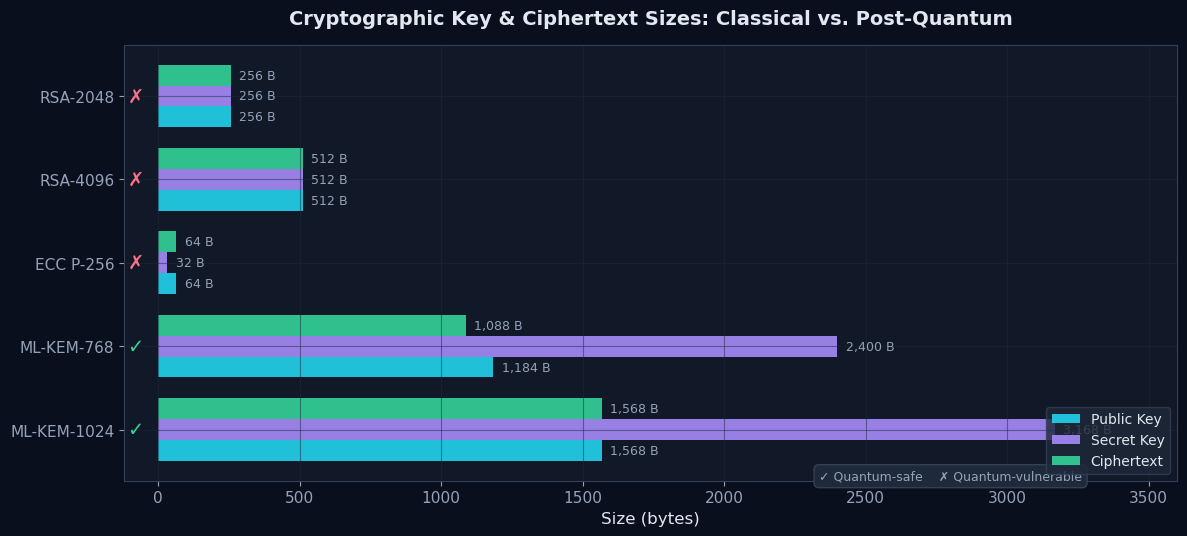

In [17]:
import numpy as np

# Data: (algorithm, public_key_bytes, secret_key_bytes, ciphertext_bytes, quantum_safe)
algorithms = [
    ("RSA-2048",     256,   256,  256,  False),
    ("RSA-4096",     512,   512,  512,  False),
    ("ECC P-256",     64,    32,   64,  False),
    ("ML-KEM-768",  1184,  2400, 1088,  True),
    ("ML-KEM-1024", 1568,  3168, 1568,  True),
]

names = [a[0] for a in algorithms]
pk_sizes = [a[1] for a in algorithms]
sk_sizes = [a[2] for a in algorithms]
ct_sizes = [a[3] for a in algorithms]
q_safe   = [a[4] for a in algorithms]

y_pos = np.arange(len(names))
bar_height = 0.25

fig, ax = plt.subplots(figsize=(12, 5.5))

# Draw grouped horizontal bars
bars_pk = ax.barh(y_pos + bar_height, pk_sizes, bar_height,
                  label='Public Key', color=ZM_CYAN, alpha=0.9, edgecolor='none')
bars_sk = ax.barh(y_pos, sk_sizes, bar_height,
                  label='Secret Key', color=ZM_VIOLET, alpha=0.9, edgecolor='none')
bars_ct = ax.barh(y_pos - bar_height, ct_sizes, bar_height,
                  label='Ciphertext', color=ZM_EMERALD, alpha=0.9, edgecolor='none')

# Annotate sizes on bars
for bars in [bars_pk, bars_sk, bars_ct]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 30, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,} B', va='center', ha='left',
                fontsize=9, color='#94a3b8')

# Mark quantum-safe algorithms
for i, safe in enumerate(q_safe):
    if safe:
        ax.text(-80, i, '\u2713', fontsize=14, color=ZM_EMERALD,
                va='center', ha='center', fontweight='bold')
    else:
        ax.text(-80, i, '\u2717', fontsize=14, color=ZM_ROSE,
                va='center', ha='center', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel('Size (bytes)', fontsize=12)
ax.set_title('Cryptographic Key & Ciphertext Sizes: Classical vs. Post-Quantum',
             fontsize=14, pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.8)
ax.set_xlim(-120, 3600)
ax.invert_yaxis()

# Add quantum-safe legend annotation
ax.text(2800, 4.6, '\u2713 Quantum-safe    \u2717 Quantum-vulnerable',
        fontsize=9, color='#94a3b8', ha='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e293b', edgecolor='#334155'))

plt.tight_layout()
plt.show()

## 7. Performance Benchmark

A common concern about post-quantum migration is performance. Will lattice-based crypto
slow down my application? The short answer: no. ML-KEM is *faster* than RSA for key
generation and encapsulation, and comparable to ECDH.

The benchmark below runs 100 complete cycles of:
1. **KeyGen** -- generate a fresh ML-KEM-768 keypair
2. **Encapsulate** -- produce a ciphertext and shared secret from the public key
3. **Decapsulate** -- recover the shared secret from the ciphertext and secret key

We measure each operation independently to show where time is spent. The Rust backend
typically completes a full cycle in under 1 ms on modern hardware. Even the Python
fallback finishes in tens of milliseconds, which is fast enough for most applications
(TLS handshakes, file encryption, credential vaults).

The histogram below shows the distribution of total cycle latencies across all 100 runs,
giving you a feel for consistency and any outliers from OS scheduling jitter.

In [18]:
import time
import numpy as np

N_ITERATIONS = 100
keygen_times = []
encap_times = []
decap_times = []

for _ in range(N_ITERATIONS):
    t0 = time.perf_counter()
    pk_b, sk_b = keypair()
    t1 = time.perf_counter()
    ct_b, ss_s = encapsulate(pk_b)
    t2 = time.perf_counter()
    ss_r = decapsulate(ct_b, sk_b)
    t3 = time.perf_counter()

    keygen_times.append((t1 - t0) * 1000)
    encap_times.append((t2 - t1) * 1000)
    decap_times.append((t3 - t2) * 1000)

keygen_arr = np.array(keygen_times)
encap_arr = np.array(encap_times)
decap_arr = np.array(decap_times)
total_arr = keygen_arr + encap_arr + decap_arr

print(f"=== ML-KEM-768 Benchmark ({N_ITERATIONS} iterations) ===")
print(f"{'Operation':<14} {'Median':>10} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 66)
for name, arr in [("KeyGen", keygen_arr), ("Encapsulate", encap_arr),
                   ("Decapsulate", decap_arr), ("Full Cycle", total_arr)]:
    print(f"{name:<14} {np.median(arr):>9.3f}ms {np.mean(arr):>9.3f}ms "
          f"{np.std(arr):>9.3f}ms {np.min(arr):>9.3f}ms {np.max(arr):>9.3f}ms")

=== ML-KEM-768 Benchmark (100 iterations) ===
Operation          Median       Mean        Std        Min        Max
------------------------------------------------------------------
KeyGen             0.038ms     0.043ms     0.020ms     0.036ms     0.178ms
Encapsulate        0.058ms     0.070ms     0.069ms     0.056ms     0.722ms
Decapsulate        0.068ms     0.081ms     0.037ms     0.065ms     0.286ms
Full Cycle         0.165ms     0.195ms     0.091ms     0.158ms     0.889ms


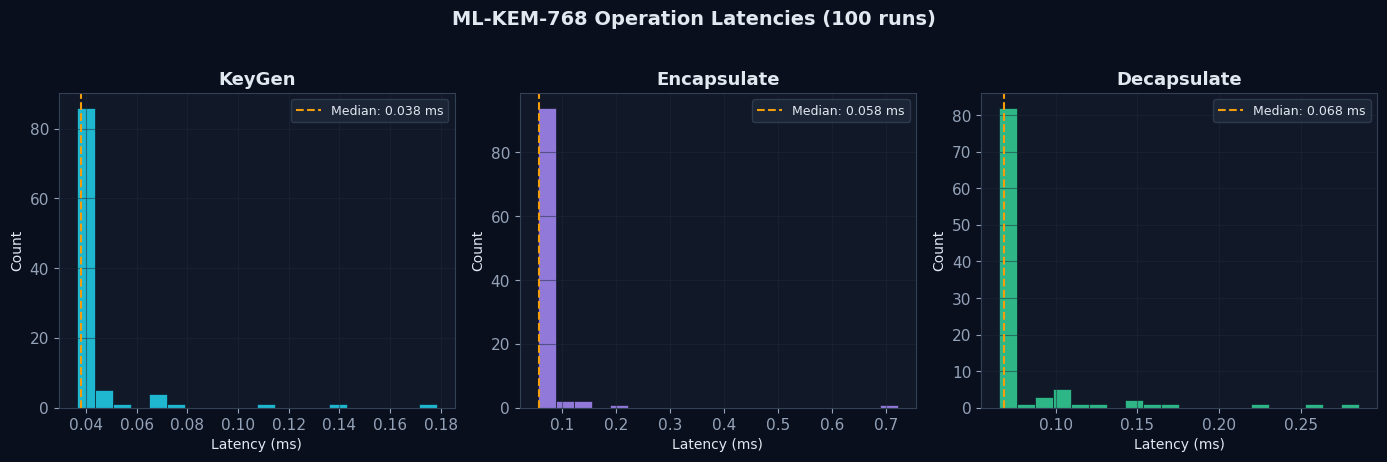

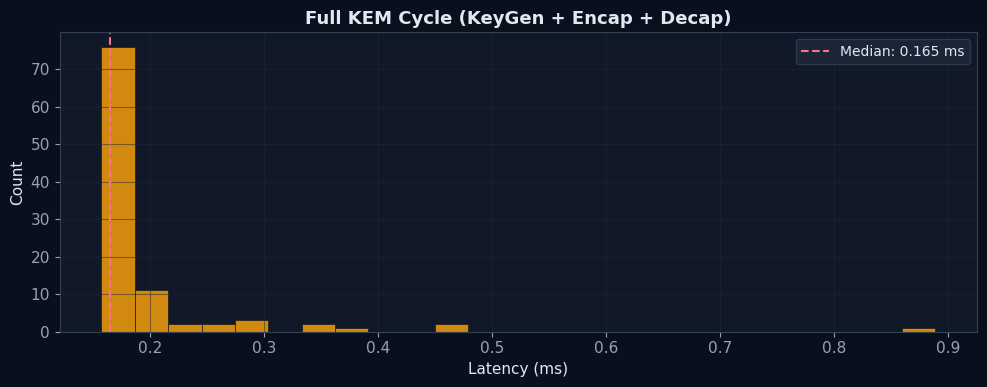

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

ops = [
    ("KeyGen",      keygen_arr, ZM_CYAN),
    ("Encapsulate",  encap_arr, ZM_VIOLET),
    ("Decapsulate",  decap_arr, ZM_EMERALD),
]

for ax, (name, data, color) in zip(axes, ops):
    ax.hist(data, bins=20, color=color, alpha=0.85, edgecolor='#0a0f1e', linewidth=0.5)
    median_val = np.median(data)
    ax.axvline(median_val, color=ZM_AMBER, linestyle='--', linewidth=1.5, label=f'Median: {median_val:.3f} ms')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Latency (ms)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle(f'ML-KEM-768 Operation Latencies ({N_ITERATIONS} runs)',
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# Also show full cycle distribution
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.hist(total_arr, bins=25, color=ZM_AMBER, alpha=0.85, edgecolor='#0a0f1e', linewidth=0.5)
median_total = np.median(total_arr)
ax2.axvline(median_total, color=ZM_ROSE, linestyle='--', linewidth=1.5,
            label=f'Median: {median_total:.3f} ms')
ax2.set_title('Full KEM Cycle (KeyGen + Encap + Decap)', fontsize=13)
ax2.set_xlabel('Latency (ms)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 8. IPython Magic Commands

Zipminator includes a set of **IPython magic commands** that make interactive PQC
exploration seamless inside Jupyter notebooks. These are loaded as an IPython extension
and provide single-line shortcuts for common operations.

Available magics after loading:

| Magic | Description |
|:------|:------------|
| `%zipminator_info` | Display SDK version, backend, security level, and entropy source |
| `%keygen` | Generate a keypair and store `pk`, `sk` in the notebook namespace |
| `%keygen --seed quantum` | Generate a keypair seeded with quantum entropy |
| `%encrypt pk` | Encapsulate using the public key; stores `ct` and `shared_secret` |
| `%decrypt ct sk` | Decapsulate; stores `recovered` |

These magics output rich HTML with color-coded results, making them ideal for
teaching and demonstrations. All generated variables (`pk`, `sk`, `ct`, `shared_secret`,
`recovered`) are injected into the notebook's namespace, so you can inspect them
in subsequent cells.

In [20]:
# Load Zipminator IPython extension
%load_ext zipminator.jupyter

# Display system info: backend, version, security parameters
%zipminator_info

The zipminator.jupyter extension is already loaded. To reload it, use:
  %reload_ext zipminator.jupyter


Version,0.5.0b1
Backend,RUST (native)
Algorithm,ML-KEM-768 (FIPS 203)
PK / SK / CT,1184 / 2400 / 1088 bytes
Shared secret,32 bytes
Entropy pool,"33,792 bytes"


## 9. DataFrame Anonymization with PII Scanning

### The PII Problem in Data Pipelines

Organizations routinely process datasets containing **Personally Identifiable Information**
(PII): names, email addresses, phone numbers, national ID numbers, and more. Regulations
like GDPR (EU), CCPA (California), and DORA (EU financial sector, effective July 2025 in
Norway) impose strict requirements on how PII is handled, stored, and shared.

Zipminator's `AdvancedAnonymizer` provides a **10-level anonymization system** that ranges
from simple regex masking (Level 1) to quantum anonymization (Level 10):

| Level | Technique | Reversible? | Use Case |
|:------|:----------|:------------|:---------|
| L1 | Regex masking | No | Quick redaction for logs |
| L2 | SHA-3 hashing | No | Deterministic de-identification |
| L3 | SHA-3 + PQC salt | No | Salted hashing (per-dataset unique) |
| L4 | Tokenization | Yes (via vault) | Reversible for authorized users |
| L5 | k-Anonymity (k>=5) | No | Quasi-identifier generalization |
| L6 | l-Diversity | No | Sensitive attribute diversity |
| L7 | QRNG noise jitter | No | Numerical perturbation |
| L8 | Differential privacy | No | Laplace mechanism, tunable epsilon |
| L9 | k-Anon + DP combined | No | Maximum statistical privacy |
| L10 | Quantum OTP mapping | No (QRNG) | Irreversible quantum anonymization (QRNG OTP) |

Below, we demonstrate Level 1 (minimal masking) on a sample dataset. The anonymizer
automatically detects PII columns and applies appropriate masking patterns.

In [21]:
import pandas as pd
from zipminator.anonymizer import AdvancedAnonymizer

# Create a sample dataset with PII
df = pd.DataFrame({
    "name":    ["Alice Johnson", "Bob Smith", "Carol Williams", "David Lee"],
    "email":   ["alice@example.com", "bob@corp.net", "carol@hospital.org", "david@school.edu"],
    "phone":   ["555-123-4567", "555-987-6543", "555-246-8135", "555-369-2580"],
    "salary":  [85000, 92000, 78000, 105000],
    "country": ["US", "NO", "SE", "UK"],
})

print("=== Original DataFrame ===")
print(df.to_string(index=False))
print()

# Initialize anonymizer (optionally with a PQC-derived seed for L3+)
anonymizer = AdvancedAnonymizer()

# Apply Level 1 anonymization: regex-based masking
level_map = {col: 1 for col in df.columns}
result = anonymizer.process(df, level_map)

print("=== Level 1 Anonymized (Regex Masking) ===")
print(result.to_string(index=False))
print()
print("Notice how names are partially obscured, emails show only domain hints,")
print("and phone numbers retain only the last 4 digits. This is the lightest level;")
print("higher levels apply hashing, generalization, or quantum noise.")

=== Original DataFrame ===
          name              email        phone  salary country
 Alice Johnson  alice@example.com 555-123-4567   85000      US
     Bob Smith       bob@corp.net 555-987-6543   92000      NO
Carol Williams carol@hospital.org 555-246-8135   78000      SE
     David Lee   david@school.edu 555-369-2580  105000      UK

=== Level 1 Anonymized (Regex Masking) ===
          name             email        phone salary country
 *********nson  a***@example.com ********4567  *5000     ***
     *****mith     b***@corp.net ********6543  *2000     ***
**********iams c***@hospital.org ********8135  *8000     ***
     ***** Lee   d***@school.edu ********2580 **5000     ***

Notice how names are partially obscured, emails show only domain hints,
and phone numbers retain only the last 4 digits. This is the lightest level;
higher levels apply hashing, generalization, or quantum noise.


### Anonymization Level Comparison

The chart below visualizes how different anonymization levels affect the information
content of the dataset. We measure "information preserved" as the ratio of non-masked
characters to total characters. Higher anonymization levels preserve less original
information, providing stronger privacy guarantees at the cost of utility.

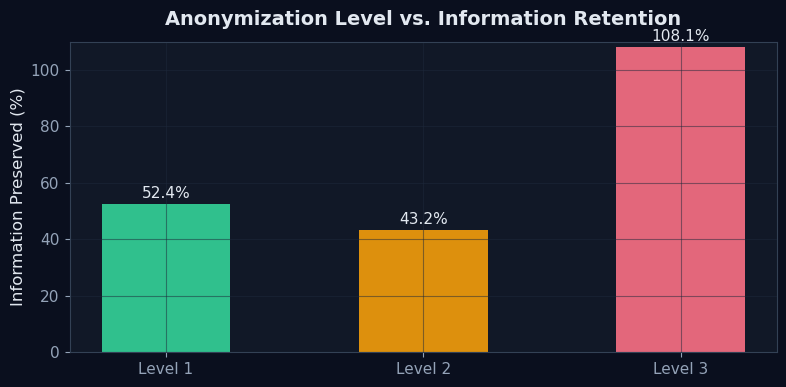

In [22]:
# Measure information retention across levels 1-3
levels_to_test = [1, 2, 3]
retention_rates = []

for level in levels_to_test:
    lm = {col: level for col in df.columns}
    try:
        anon_df = anonymizer.process(df, lm)
        # Count non-asterisk characters as "preserved"
        original_chars = sum(len(str(v)) for v in df.values.flat)
        preserved = sum(
            sum(1 for c in str(v) if c != '*')
            for v in anon_df.values.flat
        )
        retention_rates.append(preserved / original_chars * 100)
    except Exception:
        retention_rates.append(0)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [ZM_EMERALD, ZM_AMBER, ZM_ROSE]
bars = ax.bar([f'Level {l}' for l in levels_to_test], retention_rates,
              color=colors[:len(levels_to_test)], alpha=0.9, edgecolor='none', width=0.5)

for bar, rate in zip(bars, retention_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, color='#e2e8f0')

ax.set_ylabel('Information Preserved (%)', fontsize=12)
ax.set_title('Anonymization Level vs. Information Retention', fontsize=14, pad=12)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

## 10. Summary and Next Steps

### What We Covered

In this notebook, you have:

1. **Generated ML-KEM-768 keypairs** and understood the lattice-based key sizes
   (1,184 B public / 2,400 B secret / 1,088 B ciphertext).

2. **Performed KEM encapsulation and decapsulation**, establishing a shared 256-bit
   symmetric key through a quantum-resistant key exchange.

3. **Built a hybrid encryption pipeline** (ML-KEM-768 + SHA3-256 + AES-256-GCM)
   that mirrors real-world PQC deployment patterns.

4. **Compared key sizes** across RSA, ECC, and ML-KEM, seeing that the lattice-based
   overhead is modest and well within single-packet constraints.

5. **Benchmarked performance**, confirming that ML-KEM-768 runs in sub-millisecond
   time on the Rust backend.

6. **Used IPython magics** for rapid interactive PQC experimentation.

7. **Anonymized a DataFrame** using the 10-level anonymization system with automatic
   PII detection.

### Continue Learning

- **[02_anonymization.ipynb](./02_anonymization.ipynb)** -- Deep dive into all 10
  anonymization levels, PII scanning across 15 countries, and GDPR/DORA compliance.
- **[03_qrng_entropy.ipynb](./03_qrng_entropy.ipynb)** -- Quantum random number
  generation from Rigetti and IBM Quantum hardware, entropy pool management.
- **[04_compliance.ipynb](./04_compliance.ipynb)** -- DORA Art. 6/7 compliance
  workflows and cryptographic audit trails.
- **[05_shor_demo.ipynb](./05_shor_demo.ipynb)** -- Interactive demonstration of
  Shor's algorithm and why classical cryptography is vulnerable.

### Key Takeaway

The migration to post-quantum cryptography is not a future problem; it is a present
requirement. NIST finalized the standards in August 2024. NIST will deprecate RSA and
ECC by 2030. The HNDL threat means data encrypted today with classical algorithms is
already at risk. Zipminator makes PQC adoption as simple as `from zipminator import keypair`.

In [23]:
!tree

.
├── 01_quickstart.ipynb
├── 02_anonymization.ipynb
├── 03_qrng_entropy.ipynb
├── 04_compliance.ipynb
├── 05_shor_demo.ipynb
├── 06_quantum_capabilities.ipynb
├── 07_monte_carlo_prng_vs_qrng.ipynb
├── 07_vault_workflow.ipynb
├── 08_qmesh_physical_crypto.ipynb
├── 09_monte_carlo_prng_vs_qrng.ipynb
├── CLAUDE.md
└── Untitled.ipynb

1 directory, 12 files
